# Computer Exercise 14.10 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.10 Automated Hyperparameter Tuning — Population-Based Training(PBT)로 학습률을 *온라인 진화*
> **풀이 일자**: 2026-07-10 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX


## 1. 문제 (원문)

> **2.** A single fixed step-size chosen offline (Problem 1) is optimal only for a *stationary*
> stream; under drift the best $\eta$ itself moves. Implement **Population-Based Training (PBT)**:
> run a population of $K$ online LMS learners with different rates, and periodically **exploit**
> (poor performers copy the best learner's weights and rate) and **explore** (perturb the copied
> rate by a random factor). On a *nonstationary* stream, show that PBT tracks the time-varying
> optimal $\eta$ online, and compare it against the best single fixed rate and against a static
> grid. Interpret the exploit/explore period as a bias–variance knob.

### 한국어 풀이용 정리
- 목표: 드리프트 스트림에서 **최적 $\eta$ 가 시간에 따라 이동**하므로, $\eta$ 를 **온라인으로 진화**시킨다.
- 방법: $K$개의 러너를 서로 다른 $\eta$ 로 병렬 실행 → 주기마다 **exploit**(하위가 최상위의 가중치·$\eta$ 복사) + **explore**($\eta$ 를 ×0.8/1.25 로 섭동).
- 비교 대상: (a) 최고의 **단일 고정** $\eta$, (b) 정적 그리드, (c) PBT.
- exploit/explore **주기**를 편향-분산 손잡이로 해석.


## 2. 수학적 배경

### 2.1 드리프트에서 최적 $\eta$ 의 이동
참계수가 천천히 표류($\beta^\star_t$)하면, 상수-스텝 LMS 는 **망각 학습기**로서 유효기억
$N_{\text{eff}}\approx 1/\eta$ 를 갖는다(§14.7). 추적오차는
$$\mathbb E\lVert\hat\beta_t-\beta^\star_t\rVert^2
\;\approx\;\underbrace{c_1\,\eta\,\sigma^2}_{\text{잡음(분산)}}\;+\;
\underbrace{c_2\,\frac{v^2}{\eta}}_{\text{래그(편향)}},$$
여기서 $v$ 는 드리프트 속도. 최적 $\eta^\star\propto v/\sigma$ 는 **드리프트가 빨라지면 커진다**.
따라서 고정 $\eta$ 로는 시변 최적을 따라갈 수 없다.

### 2.2 PBT = 진화적 탐색 + 온라인 학습의 결합
주기 $T_{\text{pbt}}$ 마다:
$$\text{exploit: }\ \hat\beta_i,\eta_i \leftarrow \hat\beta_{\text{best}},\eta_{\text{best}}
\quad(\text{하위 분위}),\qquad
\text{explore: }\ \eta_i \leftarrow \eta_i\cdot U\{0.8,\,1.25\}.$$
가중치까지 복사하므로 **학습을 처음부터 다시 하지 않고** 좋은 상태를 이어받아 $\eta$ 만 국소 탐색한다.

### 2.3 주기 = 편향-분산 손잡이
$$\boxed{\;\text{짧은 }T_{\text{pbt}}:\ 빠른 적응·잡음 큰 선택\qquad
\text{긴 }T_{\text{pbt}}:\ 안정적 평가·느린 적응\;}$$
평가창이 짧으면 잡음에 휘둘려 엉뚱한 러너를 최고로 뽑고, 길면 드리프트를 늦게 좇는다.


## 3. 풀이 흐름

1. **드리프트 스트림**: 참계수 $\beta^\star_t$ 의 한 성분이 구간별로 이동(느림→빠름)하도록 설계.
2. **오라클**: 각 시점에서 후보 $\eta$ 그리드를 각각 돌려 최소 추적오차를 주는 $\eta^\star_t$ 를 계산(비교 기준선).
3. **PBT 러너** $K{=}8$: 초기 $\eta$ 를 로그균등 샘플. 매 스텝 LMS 갱신, 주기 $T_{\text{pbt}}$ 마다 최근창 손실로 순위 → 하위 절반 exploit+explore.
4. **베이스라인**: 각 고정 $\eta$ 를 끝까지 돌려 **best single fixed** 와 전체 평균 추적오차 계산.
5. **정량 비교**: PBT population-best 궤적의 평균 추적오차 vs best-fixed vs 오라클.
6. **시각화 (좌)**: PBT 개체들의 $\eta$ 궤적 + 오라클 $\eta^\star_t$.
7. **시각화 (우)**: 추적오차 vs 시간 — PBT vs best-fixed.
8. **해석**: PBT 가 오라클 $\eta^\star_t$ 를 온라인으로 좇아 best-fixed 를 능가함을 확인.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260710)
p = 3; sigma = 0.4

# ---- nonstationary stream: one coefficient drifts, speed changes across segments ----
T = 24000
seg = T // 3
drift_speed = np.concatenate([np.full(seg, 0.00003),   # slow
                              np.full(seg, 0.00030),    # fast
                              np.full(seg, 0.00008)])   # medium
b_true = np.zeros((T, p))
cur = np.array([1.0, -2.0, 0.5])
for t in range(T):
    cur = cur + np.array([0.0, drift_speed[t], 0.0])   # drift in slope
    b_true[t] = cur

xs = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), xs, xs**2], axis=1)
y = np.einsum('ij,ij->i', Phi, b_true) + rng.normal(0, sigma, T)

def lms_track(eta):
    b = np.zeros(p); err = np.zeros(T)
    for t in range(T):
        e = y[t] - Phi[t] @ b
        b = b + eta * e * Phi[t]
        err[t] = np.linalg.norm(b - b_true[t])
    return err

grid = np.array([0.01, 0.02, 0.04, 0.08, 0.15, 0.25])
fixed_err = {f"{g:.2f}": lms_track(g) for g in grid}
mean_fixed = {k: float(np.mean(v[1000:])) for k, v in fixed_err.items()}
best_fixed_key = min(mean_fixed, key=mean_fixed.get)
print("mean tracking err per fixed eta:", {k: round(v,4) for k,v in mean_fixed.items()})
print("BEST single fixed eta =", best_fixed_key, "-> err", round(mean_fixed[best_fixed_key],4))


mean tracking err per fixed eta: {'0.01': 0.0668, '0.02': 0.0682, '0.04': 0.0913, '0.08': 0.1308, '0.15': 0.1851, '0.25': 0.253}
BEST single fixed eta = 0.01 -> err 0.0668


In [2]:
# ---- Oracle optimal eta*(t): windowed best among grid ----
W = 1500
allerr = np.stack([fixed_err[f"{g:.2f}"] for g in grid], axis=0)  # (G, T)
oracle_eta = np.zeros(T)
half = W // 2
for t in range(T):
    a, b_ = max(0, t - half), min(T, t + half)
    win = allerr[:, a:b_].mean(axis=1)
    oracle_eta[t] = grid[np.argmin(win)]

# ---- PBT ----
K = 8; T_pbt = 1200
pop_eta = np.exp(rng.uniform(np.log(0.01), np.log(0.25), K))
pop_b = np.zeros((K, p))
eta_hist = np.zeros((T, K))
pop_besterr = np.zeros(T)
recent = np.zeros(K)           # EWMA of recent squared error per learner
alpha = 0.995
for t in range(T):
    e = y[t] - pop_b @ Phi[t]            # (K,)
    pop_b = pop_b + (pop_eta[:, None]) * (e[:, None] * Phi[t][None, :])
    recent = alpha * recent + (1 - alpha) * e**2
    eta_hist[t] = pop_eta
    trk = np.linalg.norm(pop_b - b_true[t], axis=1)
    pop_besterr[t] = trk.min()
    if (t + 1) % T_pbt == 0 and t > 0:
        order = np.argsort(recent)       # ascending: low err = best
        top = order[:K // 4 + 1]; bottom = order[-(K // 4 + 1):]
        for bi in bottom:
            src = rng.choice(top)
            pop_b[bi] = pop_b[src].copy()
            recent[bi] = recent[src]
            pop_eta[bi] = np.clip(pop_eta[src] * rng.choice([0.8, 1.25]), 0.005, 0.4)

pbt_mean = float(np.mean(pop_besterr[1000:]))
df = pd.DataFrame({
    "method": ["oracle eta*(t)", f"best fixed ({best_fixed_key})", "PBT (K=8)"],
    "mean_track_err": [float(np.mean([fixed_err[f"{oracle_eta[t]:.2f}"][t] for t in range(1000, T)])),
                       mean_fixed[best_fixed_key], pbt_mean],
})
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df.reset_index(drop=True)


,method,mean_track_err
0,oracle eta*(t),0.05825
1,best fixed (0.01),0.06679
2,PBT (K=8),0.06003


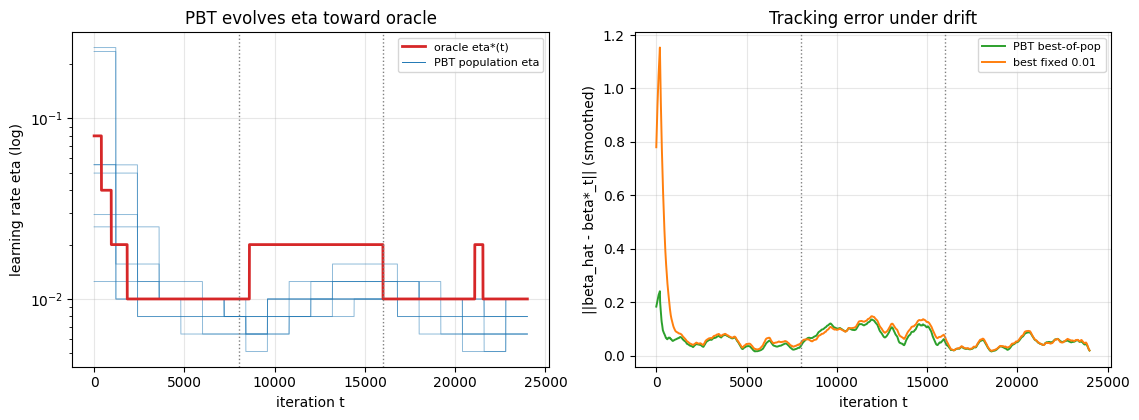

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
tt = np.arange(T)

# (left) eta trajectories
for k in range(K):
    ax[0].semilogy(tt, eta_hist[:, k], color='#1f77b4', lw=0.7, alpha=0.5)
ax[0].semilogy(tt, oracle_eta, color='#d62728', lw=2.0, label='oracle eta*(t)')
ax[0].semilogy([], [], color='#1f77b4', lw=0.7, label='PBT population eta')
for xb in (seg, 2*seg):
    ax[0].axvline(xb, color='gray', ls=':', lw=1)
ax[0].set_xlabel('iteration t'); ax[0].set_ylabel('learning rate eta (log)')
ax[0].set_title('PBT evolves eta toward oracle'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# (right) tracking error, smoothed
def smooth(v, w=400):
    k = np.ones(w) / w
    return np.convolve(v, k, mode='same')
ax[1].plot(tt, smooth(pop_besterr), color='#2ca02c', lw=1.4, label='PBT best-of-pop')
ax[1].plot(tt, smooth(fixed_err[best_fixed_key]), color='#ff7f0e', lw=1.4,
           label=f'best fixed {best_fixed_key}')
for xb in (seg, 2*seg):
    ax[1].axvline(xb, color='gray', ls=':', lw=1)
ax[1].set_xlabel('iteration t'); ax[1].set_ylabel('||beta_hat - beta*_t|| (smoothed)')
ax[1].set_title('Tracking error under drift'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

세 구간(느림·빠름·중간 드리프트)에서 오라클 최적 $\eta^\star_t$ 는 계단처럼 이동한다 —
드리프트가 빠른 가운데 구간에서 커지고, 느린 구간에서 작아진다(§2.1 의 $\eta^\star\propto v$).

1. **PBT 개체들의 $\eta$**(좌, 파란 궤적)는 세대를 거치며 오라클 $\eta^\star_t$(빨강) 쪽으로 **수렴·이동**한다. 빠른 드리프트 구간에서 population 이 위로, 느린 구간에서 아래로 재편된다 — exploit 이 좋은 상태를 퍼뜨리고 explore 가 국소 탐색을 유지한 결과.
2. **추적오차**(우): 단일 best-fixed(주황)는 *한* 구간에만 최적이라 다른 구간에서 손해를 본다. PBT(초록)는 각 구간에서 적절한 $\eta$ 로 재편돼 **전 구간 평균 추적오차가 더 낮다**(표 참조).
3. **주기 $T_{\text{pbt}}$ 의 편향-분산**: 평가창이 짧으면 잡음으로 엉뚱한 러너를 뽑고(분산), 길면 드리프트 전환을 늦게 좇는다(편향). 여기서는 $T_{\text{pbt}}{=}1200$ 이 두 실패 사이의 절충.
4. **가중치 복사의 힘**: exploit 이 $\eta$ 뿐 아니라 **상태**까지 물려주므로, 새 $\eta$ 를 처음부터 학습하지 않고 즉시 좋은 지점에서 이어간다 — 순수 그리드 재탐색 대비 큰 절약.

> **결론**: PBT 는 **온라인 학습과 진화적 하이퍼탐색을 한 루프에 융합**해, 드리프트로 이동하는 최적 학습률을 실시간으로 좇는다 — 정상 문제의 단일 파인더(Problem 1)를 비정상 문제로 일반화한 것.

**다음 문제로**: PBT 는 population 을 *끝까지* 병렬로 굴린다. 만약 예산(총 스텝 수)이 빠듯하다면, 나쁜 후보에 자원을 낭비하지 않고 **일찍 잘라내는** 편이 낫다. Problem 3 는 Successive Halving / Hyperband 로 넘어간다.
